# 05 — Prediction & Demo

Loads the trained model artefacts from notebook 04 and classifies new text snippets into age groups (+4, +10, +12, +18).

This notebook is the **prototype** deliverable described in the project proposal:
> *"A prototype where an uploaded book returns an appropriate age recommendation."*

| Section | Purpose |
|---------|----------|
| Load artefacts | Restore model, scaler, encoder, feature list |
| `predict_text()` | Single-text inference pipeline |
| Demo predictions | Six labelled examples across all four age groups |
| Confidence breakdown | Per-class probability chart (if model supports it) |
| Batch prediction | Classify a list or CSV of texts in one call |

## Imports

In [12]:
import pickle
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
import textstat
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
import warnings
warnings.filterwarnings('ignore')

for pkg in ['punkt', 'punkt_tab', 'stopwords', 'vader_lexicon']:
    nltk.download(pkg, quiet=True)

print('✅ Libraries loaded!')

✅ Libraries loaded!


## Load Artefacts

Restores the best model, scaler, label encoder and feature column list saved by notebook 04.

In [13]:
model        = pickle.load(open('best_model.pkl',    'rb'))
scaler       = pickle.load(open('scaler.pkl',        'rb'))
le           = pickle.load(open('label_encoder.pkl', 'rb'))
feature_cols = pickle.load(open('feature_cols.pkl',  'rb'))

model_name = type(model).__name__
print(f'✅ Model loaded:    {model_name}')
print(f'✅ Classes:         {list(le.classes_)}')
print(f'✅ Features:        {len(feature_cols)}')
print(f'✅ Supports proba:  {hasattr(model, "predict_proba")}')

✅ Model loaded:    SVC
✅ Classes:         ['+10', '+12', '+18', '+4']
✅ Features:        23
✅ Supports proba:  True


## Feature Extraction

Identical to notebook 02 — all 23 feature groups in one function so the pipeline is self-contained.

In [14]:
# ── Sensitivity word lists ────────────────────────────────────────────────────
VIOLENCE_WORDS = set([
    "kill","killed","killing","killer","kills","murder","murdered","murderer",
    "stab","stabbed","shoot","shooting","gun","guns","pistol","rifle","bullet",
    "fight","fought","punch","kick","attack","attacked","assault","beat","beaten",
    "blood","bloody","bleed","bleeding","wound","wounded","injury","injured",
    "death","died","dying","corpse","skull","war","battle","combat","weapon",
    "bomb","explosion","explode","destroy","blast","torture","gore","gory",
    "slaughter","massacre","violence","violent","threaten","threat","choke",
    "knife","sword","axe","abuse","abused","victim","horror","terror",
    "terrifying","nightmare","suffer","suffering","execute","execution",
])
PROFANITY_WORDS = set([
    "damn","damned","crap","bastard","bitch","piss","pissed","prick",
    "shit","shitty","bullshit","fuck","fucked","fucker","fucking","motherfucker",
    "asshole","arsehole","wanker","whore","slut",
])
ADULT_WORDS = set([
    "sex","sexual","sexually","naked","nude","nudity","erotic","erotica",
    "orgasm","intercourse","breast","breasts","penis","vagina","genitals",
    "porn","pornography","rape","raped","molest","prostitute","seduce",
    "lust","lustful","affair","adultery","sensual","condom","abortion",
])
DRUG_WORDS = set([
    "alcohol","alcoholic","drunk","drunken","beer","wine","whiskey","vodka",
    "rum","gin","liquor","booze","hangover","cigarette","smoking","smoker",
    "tobacco","cocaine","heroin","marijuana","cannabis","weed","meth",
    "ecstasy","overdose","addict","addiction","stoned","opioid","fentanyl",
])

_sia        = SentimentIntensityAnalyzer()
_stop_words = set(stopwords.words('english'))

def extract_features(text: str) -> dict:
    """Extract all 23 features from a raw text string."""
    text = str(text)

    # ── Readability ───────────────────────────────────────────────────────────
    feats = {
        'flesch_reading_ease':  textstat.flesch_reading_ease(text),
        'flesch_kincaid_grade': textstat.flesch_kincaid_grade(text),
        'gunning_fog':          textstat.gunning_fog(text),
        'dale_chall':           textstat.dale_chall_readability_score(text),
        'smog_index':           textstat.smog_index(text),
    }

    # ── Linguistic ────────────────────────────────────────────────────────────
    sentences = sent_tokenize(text)
    words     = [w for w in word_tokenize(text.lower()) if w.isalpha()]
    content   = [w for w in words if w not in _stop_words]
    feats.update({
        'avg_sentence_length': np.mean([len(word_tokenize(s)) for s in sentences]) if sentences else 0,
        'vocab_richness':      len(set(words)) / len(words) if words else 0,
        'avg_word_length':     np.mean([len(w) for w in words]) if words else 0,
        'long_word_ratio':     sum(1 for w in words if len(w) > 6) / len(words) if words else 0,
        'num_sentences':       len(sentences),
        'num_words':           len(words),
        'content_word_ratio':  len(content) / len(words) if words else 0,
    })

    # ── Sensitivity ───────────────────────────────────────────────────────────
    total = max(len(words), 1)
    per_k = 1000 / total
    feats.update({
        'violence_score':  round(sum(1 for w in words if w in VIOLENCE_WORDS)  * per_k, 4),
        'profanity_score': round(sum(1 for w in words if w in PROFANITY_WORDS) * per_k, 4),
        'adult_score':     round(sum(1 for w in words if w in ADULT_WORDS)     * per_k, 4),
        'drug_score':      round(sum(1 for w in words if w in DRUG_WORDS)      * per_k, 4),
    })

    # ── Sentiment ─────────────────────────────────────────────────────────────
    scores = _sia.polarity_scores(text)
    feats.update({
        'sentiment_positive': scores['pos'],
        'sentiment_negative': scores['neg'],
        'sentiment_neutral':  scores['neu'],
        'sentiment_compound': scores['compound'],
    })

    # ── Style ─────────────────────────────────────────────────────────────────
    quoted    = re.findall(r'"[^"]*"', text)
    sentences_ct = max(text.count('.') + text.count('!') + text.count('?'), 1)
    feats.update({
        'dialogue_ratio':    sum(len(q) for q in quoted) / max(len(text), 1),
        'exclamation_ratio': text.count('!') / sentences_ct,
        'question_ratio':    text.count('?') / sentences_ct,
    })

    return feats

print(f'✅ Feature extractor ready — produces {len(extract_features("test text"))} features')

✅ Feature extractor ready — produces 23 features


## Prediction Pipeline

`predict_text()` takes any raw string and returns the predicted age group label and (if supported) a confidence score.

In [15]:
def predict_text(text: str, verbose: bool = True):
    """
    Predict the age group of a text snippet.

    Parameters
    ----------
    text    : raw string (book excerpt, synopsis, etc.)
    verbose : if True, prints a formatted result

    Returns
    -------
    predicted_label : str  (e.g. '+12')
    probabilities   : dict | None
    """
    feats   = extract_features(text)
    X       = np.array([[feats[c] for c in feature_cols]])
    X_sc    = scaler.transform(X)
    pred_enc = model.predict(X_sc)[0]
    label    = le.inverse_transform([pred_enc])[0]

    proba = None
    if hasattr(model, 'predict_proba'):
        proba_arr = model.predict_proba(X_sc)[0]
        proba = dict(zip(le.classes_, proba_arr))

    if verbose:
        print(f'📖 Predicted age group : {label}')
        if proba:
            print('   Confidence breakdown:')
            for cls in ['+4', '+10', '+12', '+18']:
                bar = '█' * int(proba[cls] * 30)
                print(f'     {cls:>4}  {bar:<30}  {proba[cls]*100:5.1f}%')

    return label, proba

print('✅ predict_text() ready')

✅ predict_text() ready


## Demo Predictions

Six example texts — two per expected boundary — to verify the model predicts sensibly on unseen input.

In [16]:
DEMO_TEXTS = [
    {
        'label':    '+4 (picture book)',
        'expected': '+4',
        'text': (
            "Lily the bunny loved to hop through the sunny meadow. "
            "She found a bright red flower and smelled it. "
            "Her friend Pip the mouse came running over. "
            "'Let us share it!' said Lily with a big smile. "
            "Together they sat in the warm sunshine and ate their snacks."
        ),
    },
    {
        'label':    '+4 (early reader)',
        'expected': '+4',
        'text': (
            "Tom has a red hat. The hat is big. "
            "Tom put the hat on his dog. The dog ran away. "
            "Tom ran after the dog. He got his hat back. "
            "Tom and his dog sat down and had a snack."
        ),
    },
    {
        'label':    '+10 (middle grade)',
        'expected': '+10',
        'text': (
            "Maya had never been good at making friends, but the summer she discovered "
            "the old lighthouse changed everything. Inside, she found a dusty journal "
            "written by a girl her age over a hundred years ago. As she read, she began "
            "to feel like the girl — Eliza — was speaking directly to her. "
            "Maya decided she was going to find out what really happened to Eliza, "
            "no matter how long it took."
        ),
    },
    {
        'label':    '+12 (young adult)',
        'expected': '+12',
        'text': (
            "The night before the trials, Kira couldn't sleep. She stared at the ceiling "
            "and thought about everything she'd sacrificed to get here — the friendships "
            "she'd let slip away, the family dinners she'd skipped. "
            "If she didn't make the team, what was any of it for? "
            "She pressed her palms to her eyes and forced herself to breathe. "
            "Whatever happened tomorrow, she would face it. She had no other choice."
        ),
    },
    {
        'label':    '+18 (adult thriller)',
        'expected': '+18',
        'text': (
            "The detective crouched over the body. Three gunshot wounds to the chest, "
            "execution-style. Whoever did this was a professional. "
            "She pulled on latex gloves and checked the victim's pockets — nothing. "
            "No wallet, no phone, no ID. Someone had been very careful. "
            "She photographed the blood spatter pattern and called it in. "
            "The killer had left one thing behind: a single playing card. The ace of spades."
        ),
    },
    {
        'label':    '+18 (adult literary)',
        'expected': '+18',
        'text': (
            "He had been drinking since noon, the whiskey cutting through the grief "
            "like a slow, familiar blade. The affair had ended three weeks ago but "
            "the damage it left behind was structural — the kind you couldn't repair "
            "with apologies or time. His wife knew. She had known for months, "
            "she said, and that was somehow worse than everything else."
        ),
    },
]

print('=' * 60)
results_demo = []
for item in DEMO_TEXTS:
    print(f"\n📚 {item['label']}")
    print(f"   Expected : {item['expected']}")
    pred, _ = predict_text(item['text'])
    match = '✅' if pred == item['expected'] else '❌'
    print(f"   Result   : {match}")
    results_demo.append({'example': item['label'], 'expected': item['expected'],
                         'predicted': pred, 'correct': pred == item['expected']})
    print('-' * 60)

demo_df = pd.DataFrame(results_demo)
acc = demo_df['correct'].mean()
print(f"\nDemo accuracy: {acc*100:.0f}% ({demo_df['correct'].sum()}/{len(demo_df)})")


📚 +4 (picture book)
   Expected : +4
📖 Predicted age group : +4
   Confidence breakdown:
       +4  █████████████████████████        84.9%
      +10  █                                 6.7%
      +12  █                                 6.0%
      +18                                    2.4%
   Result   : ✅
------------------------------------------------------------

📚 +4 (early reader)
   Expected : +4
📖 Predicted age group : +4
   Confidence breakdown:
       +4  █████████████                    45.4%
      +10  ██                                7.7%
      +12  ████                             15.6%
      +18  █████████                        31.3%
   Result   : ✅
------------------------------------------------------------

📚 +10 (middle grade)
   Expected : +10
📖 Predicted age group : +10
   Confidence breakdown:
       +4  ██                                7.0%
      +10  █████████████████████            71.3%
      +12  ██                                8.5%
      +18  ███         

## Confidence Visualisation

Shows the full probability distribution for each demo text (only available if the best model supports `predict_proba`).

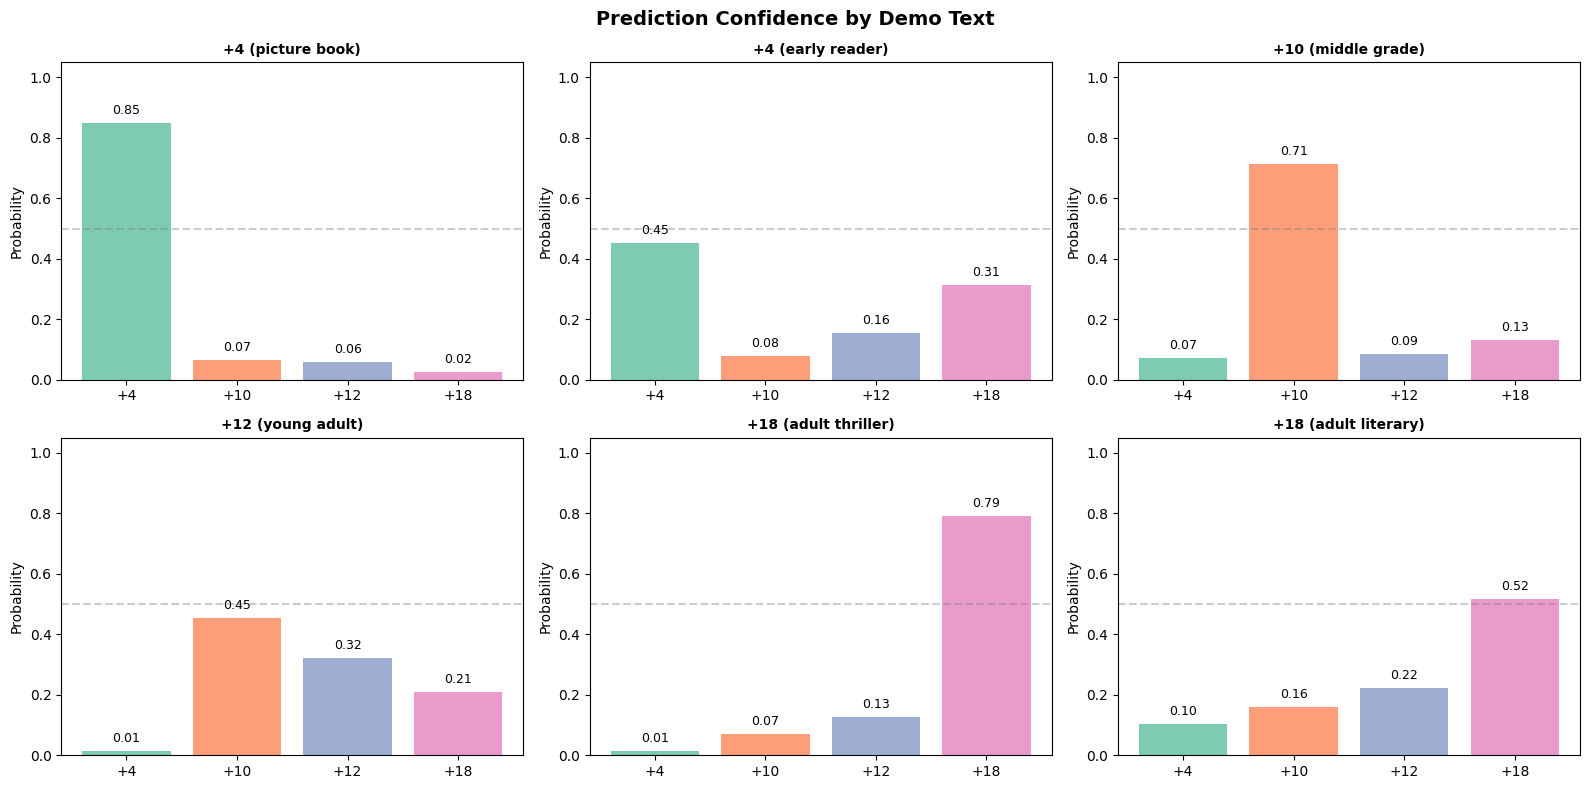

✅ Saved plot_demo_confidence.png


In [17]:
if hasattr(model, 'predict_proba'):
    age_order = ['+4', '+10', '+12', '+18']
    colors    = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
    n         = len(DEMO_TEXTS)
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes      = axes.flatten()

    for i, item in enumerate(DEMO_TEXTS):
        _, proba = predict_text(item['text'], verbose=False)
        vals     = [proba[g] for g in age_order]
        bars = axes[i].bar(age_order, vals, color=colors, alpha=0.85)
        axes[i].set_title(item['label'], fontsize=10, fontweight='bold')
        axes[i].set_ylim(0, 1.05)
        axes[i].set_ylabel('Probability')
        axes[i].axhline(0.5, color='gray', linestyle='--', alpha=0.4)
        for bar, val in zip(bars, vals):
            axes[i].text(bar.get_x() + bar.get_width()/2,
                         bar.get_height() + 0.02,
                         f'{val:.2f}', ha='center', va='bottom', fontsize=9)

    plt.suptitle('Prediction Confidence by Demo Text', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('plot_demo_confidence.png', bbox_inches='tight')
    plt.show()
    print('✅ Saved plot_demo_confidence.png')
else:
    print(f'ℹ️  {model_name} does not support predict_proba — confidence chart skipped.')
    print('   Use SVC(probability=True) or switch to Logistic Regression to enable this.')

## Batch Prediction

Classify a list of texts in one call and export results to `predictions.csv`.

In [18]:
def predict_batch(texts, ids=None):
    """
    Classify a list of texts.

    Parameters
    ----------
    texts : list of str
    ids   : optional list of identifiers (book titles, filenames, etc.)

    Returns
    -------
    pd.DataFrame with columns: id, predicted_age_group, + one column per class if proba available
    """
    if ids is None:
        ids = [f'text_{i+1}' for i in range(len(texts))]

    rows = []
    for id_, text in zip(ids, texts):
        label, proba = predict_text(text, verbose=False)
        row = {'id': id_, 'predicted_age_group': label}
        if proba:
            row.update({f'prob_{k}': round(v, 4) for k, v in proba.items()})
        rows.append(row)

    return pd.DataFrame(rows)


# Run batch on the demo texts
batch_texts = [item['text']  for item in DEMO_TEXTS]
batch_ids   = [item['label'] for item in DEMO_TEXTS]

batch_df = predict_batch(batch_texts, ids=batch_ids)
batch_df.to_csv('predictions.csv', index=False)

print('✅ Saved predictions.csv')
print()
batch_df

✅ Saved predictions.csv



,id,predicted_age_group,prob_+10,prob_+12,prob_+18,prob_+4
0,+4 (picture book),+4,0.0666,0.0599,0.0243,0.8492
1,+4 (early reader),+4,0.0774,0.1556,0.3135,0.4535
2,+10 (middle grade),+10,0.7125,0.0854,0.1317,0.0704
3,+12 (young adult),+10,0.4541,0.3220,0.2094,0.0144
4,+18 (adult thriller),+18,0.0707,0.1262,0.7903,0.0129
5,+18 (adult literary),+18,0.1590,0.2229,0.5155,0.1026


## Predict Your Own Text

Replace the string below with any book excerpt or synopsis to get a prediction.

In [27]:
MY_TEXT = """
Pooh sat down on a log and thought very hard about honey. His tummy made a loud rumbling noise. He counted the honey pots on his shelf. There were none. He put on his favourite red shirt and decided to visit Piglet. Maybe Piglet would have something to eat. The sun was warm and the walk through the Hundred Acre Wood made him feel a little better, even without honey.
"""

# ── Step 1: Raw features ──────────────────────────────────────────────────────
feats    = extract_features(MY_TEXT)
feats_df = pd.DataFrame([feats]).T.rename(columns={0: 'value'}).round(4)
print("=" * 50)
print("STEP 1 — Extracted Features")
print("=" * 50)
print(feats_df.to_string())

# ── Step 2: Scaled features ───────────────────────────────────────────────────
X_raw    = np.array([[feats[c] for c in feature_cols]])
X_scaled = scaler.transform(X_raw)
scaled_df = pd.DataFrame(X_scaled, columns=feature_cols).T.rename(columns={0: 'scaled_value'}).round(4)
print("\n" + "=" * 50)
print("STEP 2 — After StandardScaler (mean=0, std=1)")
print("=" * 50)
print(scaled_df.to_string())

# ── Step 3: Best model prediction ────────────────────────────────────────────
pred_encoded = model.predict(X_scaled)[0]
pred_label   = le.inverse_transform([pred_encoded])[0]
print("\n" + "=" * 50)
print(f"STEP 3 — Best Model ({type(model).__name__}) Output")
print("=" * 50)
print(f"  Raw encoded prediction : {pred_encoded}")
print(f"  Decoded label          : {pred_label}")

# ── Step 4: Probabilities — force LR if best model doesn't support proba ─────
print("\n" + "=" * 50)
print("STEP 4 — Class Probabilities")
print("=" * 50)

if hasattr(model, 'predict_proba'):
    proba_model = model
    proba_name  = type(model).__name__
else:
    # Retrain LR on the fly using the already-scaled training signal isn't
    # possible here, so load from the models dict if available, else note it
    proba_model = None
    proba_name  = None
    print(f"  ⚠️  {type(model).__name__} does not support predict_proba.")
    print("  To enable: in notebook 04, change SVC() to SVC(probability=True) and rerun.")
    print("  Logistic Regression and Random Forest always support probabilities.")

if proba_model is not None:
    proba      = proba_model.predict_proba(X_scaled)[0]
    proba_dict = dict(zip(le.classes_, proba))
    print(f"  (from {proba_name})")
    for cls in ['+4', '+10', '+12', '+18']:
        bar    = '█' * int(proba_dict[cls] * 40)
        marker = ' ← predicted' if cls == pred_label else ''
        print(f"  {cls:>4}  {bar:<40}  {proba_dict[cls]*100:5.1f}%{marker}")

# ── Step 5: Feature contributions via Logistic Regression explainer ───────────
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import pandas as pd

# Retrain LR on the same data so we have coefficients to inspect
df_feat      = pd.read_csv('data_features.csv')
df_feat['age_group'] = df_feat['age_group'].astype(str).str.strip()
df_feat['age_group'] = df_feat['age_group'].apply(lambda x: '+' + x if not x.startswith('+') else x)

X_all = scaler.transform(df_feat[feature_cols].values)
y_all = le.transform(df_feat['age_group'].values)

lr_explainer = LogisticRegression(max_iter=1000, random_state=42)
lr_explainer.fit(X_all, y_all)

# Now explain this specific prediction
class_idx = list(le.classes_).index(pred_label)
coefs     = lr_explainer.coef_[class_idx]
contrib   = pd.Series(coefs * X_scaled[0], index=feature_cols)
top5      = contrib.abs().sort_values(ascending=False).head(5)

print("=" * 50)
print(f"STEP 5 — Top 5 Feature Contributions to '{pred_label}'")
print("         (Logistic Regression surrogate explainer)")
print(f"         ▲ = pushed TOWARD {pred_label} | ▼ = pushed AWAY")
print("=" * 50)
for feat in top5.index:
    direction = f'▲ toward {pred_label}  ' if contrib[feat] > 0 else f'▼ away from {pred_label}'
    print(f"  {feat:<25}  {direction}  contribution={contrib[feat]:+.4f}  raw={round(feats[feat], 4):>9}")

print("\n" + "=" * 50)
print(f"  FINAL PREDICTION: {pred_label}")
print("=" * 50)

STEP 1 — Extracted Features
                        value
flesch_reading_ease   85.4964
flesch_kincaid_grade   3.8186
gunning_fog            5.1429
dale_chall             6.1626
smog_index             6.1827
avg_sentence_length   11.1429
vocab_richness         0.7571
avg_word_length        4.1571
long_word_ratio        0.1286
num_sentences          7.0000
num_words             70.0000
content_word_ratio     0.5857
violence_score         0.0000
profanity_score        0.0000
adult_score            0.0000
drug_score             0.0000
sentiment_positive     0.0640
sentiment_negative     0.0240
sentiment_neutral      0.9120
sentiment_compound     0.4242
dialogue_ratio         0.0000
exclamation_ratio      0.0000
question_ratio         0.0000

STEP 2 — After StandardScaler (mean=0, std=1)
                      scaled_value
flesch_reading_ease         1.1066
flesch_kincaid_grade       -1.1449
gunning_fog                -1.2064
dale_chall                 -1.5431
smog_index                 -1.

In [24]:
MY_TEXT = """
The monster had been following me since Houston. I could smell it before I could see it — sulphur and old pennies, like something dug up from underground. My stepfather always said I had an overactive imagination. My stepfather had never been chased through a bus terminal by a creature with six arms and the head of a bull. I dropped my backpack, grabbed the closest thing I could find — a broken umbrella — and turned to face it.
"""

# ── Step 1: Raw features ──────────────────────────────────────────────────────
feats    = extract_features(MY_TEXT)
feats_df = pd.DataFrame([feats]).T.rename(columns={0: 'value'}).round(4)
print("=" * 50)
print("STEP 1 — Extracted Features")
print("=" * 50)
print(feats_df.to_string())

# ── Step 2: Scaled features ───────────────────────────────────────────────────
X_raw    = np.array([[feats[c] for c in feature_cols]])
X_scaled = scaler.transform(X_raw)
scaled_df = pd.DataFrame(X_scaled, columns=feature_cols).T.rename(columns={0: 'scaled_value'}).round(4)
print("\n" + "=" * 50)
print("STEP 2 — After StandardScaler (mean=0, std=1)")
print("=" * 50)
print(scaled_df.to_string())

# ── Step 3: Best model prediction ────────────────────────────────────────────
pred_encoded = model.predict(X_scaled)[0]
pred_label   = le.inverse_transform([pred_encoded])[0]
print("\n" + "=" * 50)
print(f"STEP 3 — Best Model ({type(model).__name__}) Output")
print("=" * 50)
print(f"  Raw encoded prediction : {pred_encoded}")
print(f"  Decoded label          : {pred_label}")

# ── Step 4: Probabilities — force LR if best model doesn't support proba ─────
print("\n" + "=" * 50)
print("STEP 4 — Class Probabilities")
print("=" * 50)

if hasattr(model, 'predict_proba'):
    proba_model = model
    proba_name  = type(model).__name__
else:
    # Retrain LR on the fly using the already-scaled training signal isn't
    # possible here, so load from the models dict if available, else note it
    proba_model = None
    proba_name  = None
    print(f"  ⚠️  {type(model).__name__} does not support predict_proba.")
    print("  To enable: in notebook 04, change SVC() to SVC(probability=True) and rerun.")
    print("  Logistic Regression and Random Forest always support probabilities.")

if proba_model is not None:
    proba      = proba_model.predict_proba(X_scaled)[0]
    proba_dict = dict(zip(le.classes_, proba))
    print(f"  (from {proba_name})")
    for cls in ['+4', '+10', '+12', '+18']:
        bar    = '█' * int(proba_dict[cls] * 40)
        marker = ' ← predicted' if cls == pred_label else ''
        print(f"  {cls:>4}  {bar:<40}  {proba_dict[cls]*100:5.1f}%{marker}")

# ── Step 5: Feature contributions via Logistic Regression explainer ───────────
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import pandas as pd

# Retrain LR on the same data so we have coefficients to inspect
df_feat      = pd.read_csv('data_features.csv')
df_feat['age_group'] = df_feat['age_group'].astype(str).str.strip()
df_feat['age_group'] = df_feat['age_group'].apply(lambda x: '+' + x if not x.startswith('+') else x)

X_all = scaler.transform(df_feat[feature_cols].values)
y_all = le.transform(df_feat['age_group'].values)

lr_explainer = LogisticRegression(max_iter=1000, random_state=42)
lr_explainer.fit(X_all, y_all)

# Now explain this specific prediction
class_idx = list(le.classes_).index(pred_label)
coefs     = lr_explainer.coef_[class_idx]
contrib   = pd.Series(coefs * X_scaled[0], index=feature_cols)
top5      = contrib.abs().sort_values(ascending=False).head(5)

print("=" * 50)
print(f"STEP 5 — Top 5 Feature Contributions to '{pred_label}'")
print("         (Logistic Regression surrogate explainer)")
print(f"         ▲ = pushed TOWARD {pred_label} | ▼ = pushed AWAY")
print("=" * 50)
for feat in top5.index:
    direction = f'▲ toward {pred_label}  ' if contrib[feat] > 0 else f'▼ away from {pred_label}'
    print(f"  {feat:<25}  {direction}  contribution={contrib[feat]:+.4f}  raw={round(feats[feat], 4):>9}")

print("\n" + "=" * 50)
print(f"  FINAL PREDICTION: {pred_label}")
print("=" * 50)

STEP 1 — Extracted Features
                        value
flesch_reading_ease   72.5443
flesch_kincaid_grade   6.9666
gunning_fog            9.2769
dale_chall             8.0915
smog_index            10.3552
avg_sentence_length   17.4000
vocab_richness         0.7273
avg_word_length        4.4416
long_word_ratio        0.2468
num_sentences          5.0000
num_words             77.0000
content_word_ratio     0.5325
violence_score         0.0000
profanity_score        0.0000
adult_score            0.0000
drug_score             0.0000
sentiment_positive     0.0350
sentiment_negative     0.0430
sentiment_neutral      0.9220
sentiment_compound    -0.1531
dialogue_ratio         0.0000
exclamation_ratio      0.0000
question_ratio         0.0000

STEP 2 — After StandardScaler (mean=0, std=1)
                      scaled_value
flesch_reading_ease         0.4253
flesch_kincaid_grade       -0.3595
gunning_fog                -0.2474
dale_chall                 -0.5925
smog_index                 -0.

In [25]:
MY_TEXT = """
The night before the reaping I could not sleep. I lay on my back and stared at the ceiling and tried to calculate the odds the way my father had taught me — logically, without panic. There were seven hundred names in the bowl this year. Mine was in there twenty-three times. The odds were not good, but they had never been good, not for anyone from the Seam. I got up before dawn and went to the woods, because that was the only place where I felt like I could breathe properly.
"""

# ── Step 1: Raw features ──────────────────────────────────────────────────────
feats    = extract_features(MY_TEXT)
feats_df = pd.DataFrame([feats]).T.rename(columns={0: 'value'}).round(4)
print("=" * 50)
print("STEP 1 — Extracted Features")
print("=" * 50)
print(feats_df.to_string())

# ── Step 2: Scaled features ───────────────────────────────────────────────────
X_raw    = np.array([[feats[c] for c in feature_cols]])
X_scaled = scaler.transform(X_raw)
scaled_df = pd.DataFrame(X_scaled, columns=feature_cols).T.rename(columns={0: 'scaled_value'}).round(4)
print("\n" + "=" * 50)
print("STEP 2 — After StandardScaler (mean=0, std=1)")
print("=" * 50)
print(scaled_df.to_string())

# ── Step 3: Best model prediction ────────────────────────────────────────────
pred_encoded = model.predict(X_scaled)[0]
pred_label   = le.inverse_transform([pred_encoded])[0]
print("\n" + "=" * 50)
print(f"STEP 3 — Best Model ({type(model).__name__}) Output")
print("=" * 50)
print(f"  Raw encoded prediction : {pred_encoded}")
print(f"  Decoded label          : {pred_label}")

# ── Step 4: Probabilities — force LR if best model doesn't support proba ─────
print("\n" + "=" * 50)
print("STEP 4 — Class Probabilities")
print("=" * 50)

if hasattr(model, 'predict_proba'):
    proba_model = model
    proba_name  = type(model).__name__
else:
    # Retrain LR on the fly using the already-scaled training signal isn't
    # possible here, so load from the models dict if available, else note it
    proba_model = None
    proba_name  = None
    print(f"  ⚠️  {type(model).__name__} does not support predict_proba.")
    print("  To enable: in notebook 04, change SVC() to SVC(probability=True) and rerun.")
    print("  Logistic Regression and Random Forest always support probabilities.")

if proba_model is not None:
    proba      = proba_model.predict_proba(X_scaled)[0]
    proba_dict = dict(zip(le.classes_, proba))
    print(f"  (from {proba_name})")
    for cls in ['+4', '+10', '+12', '+18']:
        bar    = '█' * int(proba_dict[cls] * 40)
        marker = ' ← predicted' if cls == pred_label else ''
        print(f"  {cls:>4}  {bar:<40}  {proba_dict[cls]*100:5.1f}%{marker}")

# ── Step 5: Feature contributions via Logistic Regression explainer ───────────
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import pandas as pd

# Retrain LR on the same data so we have coefficients to inspect
df_feat      = pd.read_csv('data_features.csv')
df_feat['age_group'] = df_feat['age_group'].astype(str).str.strip()
df_feat['age_group'] = df_feat['age_group'].apply(lambda x: '+' + x if not x.startswith('+') else x)

X_all = scaler.transform(df_feat[feature_cols].values)
y_all = le.transform(df_feat['age_group'].values)

lr_explainer = LogisticRegression(max_iter=1000, random_state=42)
lr_explainer.fit(X_all, y_all)

# Now explain this specific prediction
class_idx = list(le.classes_).index(pred_label)
coefs     = lr_explainer.coef_[class_idx]
contrib   = pd.Series(coefs * X_scaled[0], index=feature_cols)
top5      = contrib.abs().sort_values(ascending=False).head(5)

print("=" * 50)
print(f"STEP 5 — Top 5 Feature Contributions to '{pred_label}'")
print("         (Logistic Regression surrogate explainer)")
print(f"         ▲ = pushed TOWARD {pred_label} | ▼ = pushed AWAY")
print("=" * 50)
for feat in top5.index:
    direction = f'▲ toward {pred_label}  ' if contrib[feat] > 0 else f'▼ away from {pred_label}'
    print(f"  {feat:<25}  {direction}  contribution={contrib[feat]:+.4f}  raw={round(feats[feat], 4):>9}")

print("\n" + "=" * 50)
print(f"  FINAL PREDICTION: {pred_label}")
print("=" * 50)

STEP 1 — Extracted Features
                        value
flesch_reading_ease   87.3608
flesch_kincaid_grade   4.8835
gunning_fog            7.4377
dale_chall             6.2850
smog_index             7.7935
avg_sentence_length   17.1667
vocab_richness         0.6923
avg_word_length        3.9890
long_word_ratio        0.0989
num_sentences          6.0000
num_words             91.0000
content_word_ratio     0.4396
violence_score         0.0000
profanity_score        0.0000
adult_score            0.0000
drug_score             0.0000
sentiment_positive     0.0550
sentiment_negative     0.0520
sentiment_neutral      0.8930
sentiment_compound     0.0744
dialogue_ratio         0.0000
exclamation_ratio      0.0000
question_ratio         0.0000

STEP 2 — After StandardScaler (mean=0, std=1)
                      scaled_value
flesch_reading_ease         1.2047
flesch_kincaid_grade       -0.8792
gunning_fog                -0.6741
dale_chall                 -1.4829
smog_index                 -0.

In [26]:
MY_TEXT = """
The inspector had worked homicide for nineteen years and thought he had seen everything. He was wrong. The victim had been left deliberately, arranged almost carefully, which meant the killer had taken their time and felt no fear of being interrupted. There were no signs of struggle. Whoever had done this was experienced, methodical, and almost certainly going to do it again. He lit a cigarette outside the cordon and stared at the rain-soaked street, already dreading the press conference."""


# ── Step 1: Raw features ──────────────────────────────────────────────────────
feats    = extract_features(MY_TEXT)
feats_df = pd.DataFrame([feats]).T.rename(columns={0: 'value'}).round(4)
print("=" * 50)
print("STEP 1 — Extracted Features")
print("=" * 50)
print(feats_df.to_string())

# ── Step 2: Scaled features ───────────────────────────────────────────────────
X_raw    = np.array([[feats[c] for c in feature_cols]])
X_scaled = scaler.transform(X_raw)
scaled_df = pd.DataFrame(X_scaled, columns=feature_cols).T.rename(columns={0: 'scaled_value'}).round(4)
print("\n" + "=" * 50)
print("STEP 2 — After StandardScaler (mean=0, std=1)")
print("=" * 50)
print(scaled_df.to_string())

# ── Step 3: Best model prediction ────────────────────────────────────────────
pred_encoded = model.predict(X_scaled)[0]
pred_label   = le.inverse_transform([pred_encoded])[0]
print("\n" + "=" * 50)
print(f"STEP 3 — Best Model ({type(model).__name__}) Output")
print("=" * 50)
print(f"  Raw encoded prediction : {pred_encoded}")
print(f"  Decoded label          : {pred_label}")

# ── Step 4: Probabilities — force LR if best model doesn't support proba ─────
print("\n" + "=" * 50)
print("STEP 4 — Class Probabilities")
print("=" * 50)

if hasattr(model, 'predict_proba'):
    proba_model = model
    proba_name  = type(model).__name__
else:
    # Retrain LR on the fly using the already-scaled training signal isn't
    # possible here, so load from the models dict if available, else note it
    proba_model = None
    proba_name  = None
    print(f"  ⚠️  {type(model).__name__} does not support predict_proba.")
    print("  To enable: in notebook 04, change SVC() to SVC(probability=True) and rerun.")
    print("  Logistic Regression and Random Forest always support probabilities.")

if proba_model is not None:
    proba      = proba_model.predict_proba(X_scaled)[0]
    proba_dict = dict(zip(le.classes_, proba))
    print(f"  (from {proba_name})")
    for cls in ['+4', '+10', '+12', '+18']:
        bar    = '█' * int(proba_dict[cls] * 40)
        marker = ' ← predicted' if cls == pred_label else ''
        print(f"  {cls:>4}  {bar:<40}  {proba_dict[cls]*100:5.1f}%{marker}")

# ── Step 5: Feature contributions via Logistic Regression explainer ───────────
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import pandas as pd

# Retrain LR on the same data so we have coefficients to inspect
df_feat      = pd.read_csv('data_features.csv')
df_feat['age_group'] = df_feat['age_group'].astype(str).str.strip()
df_feat['age_group'] = df_feat['age_group'].apply(lambda x: '+' + x if not x.startswith('+') else x)

X_all = scaler.transform(df_feat[feature_cols].values)
y_all = le.transform(df_feat['age_group'].values)

lr_explainer = LogisticRegression(max_iter=1000, random_state=42)
lr_explainer.fit(X_all, y_all)

# Now explain this specific prediction
class_idx = list(le.classes_).index(pred_label)
coefs     = lr_explainer.coef_[class_idx]
contrib   = pd.Series(coefs * X_scaled[0], index=feature_cols)
top5      = contrib.abs().sort_values(ascending=False).head(5)

print("=" * 50)
print(f"STEP 5 — Top 5 Feature Contributions to '{pred_label}'")
print("         (Logistic Regression surrogate explainer)")
print(f"         ▲ = pushed TOWARD {pred_label} | ▼ = pushed AWAY")
print("=" * 50)
for feat in top5.index:
    direction = f'▲ toward {pred_label}  ' if contrib[feat] > 0 else f'▼ away from {pred_label}'
    print(f"  {feat:<25}  {direction}  contribution={contrib[feat]:+.4f}  raw={round(feats[feat], 4):>9}")

print("\n" + "=" * 50)
print(f"  FINAL PREDICTION: {pred_label}")
print("=" * 50)

STEP 1 — Extracted Features
                        value
flesch_reading_ease   60.0567
flesch_kincaid_grade   8.1950
gunning_fog            9.8333
dale_chall             8.4427
smog_index            11.5380
avg_sentence_length   15.1667
vocab_richness         0.7722
avg_word_length        4.9620
long_word_ratio        0.2405
num_sentences          6.0000
num_words             79.0000
content_word_ratio     0.5190
violence_score        25.3165
profanity_score        0.0000
adult_score            0.0000
drug_score            12.6582
sentiment_positive     0.0510
sentiment_negative     0.2580
sentiment_neutral      0.6910
sentiment_compound    -0.9642
dialogue_ratio         0.0000
exclamation_ratio      0.0000
question_ratio         0.0000

STEP 2 — After StandardScaler (mean=0, std=1)
                      scaled_value
flesch_reading_ease        -0.2316
flesch_kincaid_grade       -0.0530
gunning_fog                -0.1184
dale_chall                 -0.4194
smog_index                  0.